In [1]:
import matplotlib.pyplot as plt
import numpy as np

from utils.fit_data import ResonanceFitData
from utils.pendulums_data import PendulumsData, prepare_data
from utils.plotting import (
    bar_chart,
    plot_all,
    plot_fft_results_all,
    plot_fft_results_each,
    save_plot,
)

In [2]:
lengths = np.array([0.97, 0.99, 0.995, 1.0])
labels = ["97cm", "99cm", "99.5cm", "100cm"]

cols = ["mass A", "mass B", "mass C", "mass D"]
L_d = 1.0

In [3]:
df = prepare_data("../data/session-6/doubled-mass.csv", cols)

doubled_mass = PendulumsData(cols, labels, lengths, df)
doubled_mass.preprocess_offsets()
doubled_mass.normalize()
doubled_mass_fit = ResonanceFitData(L_d, doubled_mass)

In [4]:
df = prepare_data("../data/session-4/from5toEnd.csv", cols)
df["t"] += 300

baseline = PendulumsData(cols, labels, lengths, df)
baseline.preprocess_offsets()
baseline.normalize()
baseline_fit = ResonanceFitData(L_d, baseline)

In [5]:
doubled_mass_fit.perform_fft()

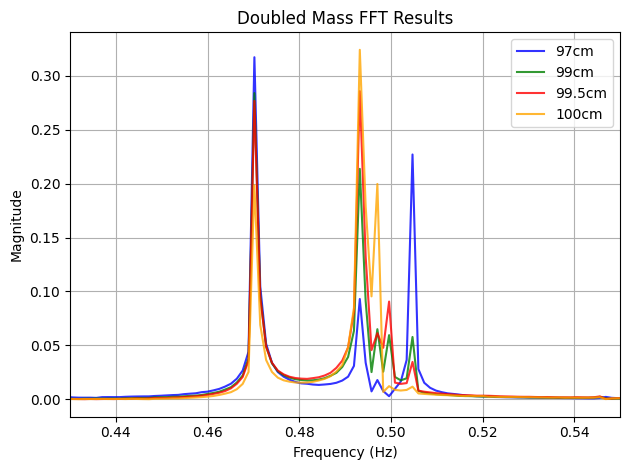

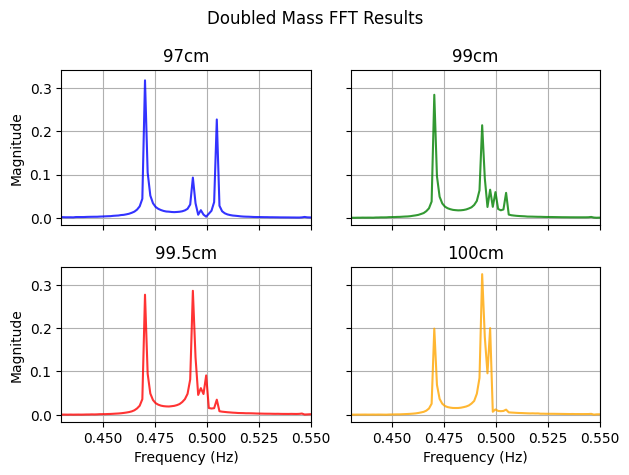

In [6]:
plot_fft_results_all(
    doubled_mass_fit.fft_results,
    title="Doubled Mass FFT Results",
    labels=doubled_mass.labels,
)
save_plot("salvaging/doubled_mass_fft_results.pdf")
plt.show()
plot_fft_results_each(
    doubled_mass_fit.fft_results,
    title="Doubled Mass FFT Results",
    labels=doubled_mass.labels,
)
save_plot("salvaging/doubled_mass_fft_results_each.pdf")
plt.show()

In [7]:
baseline_fit.perform_fft()

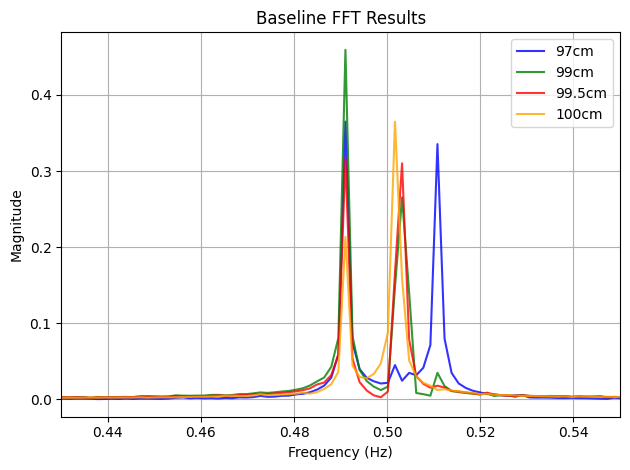

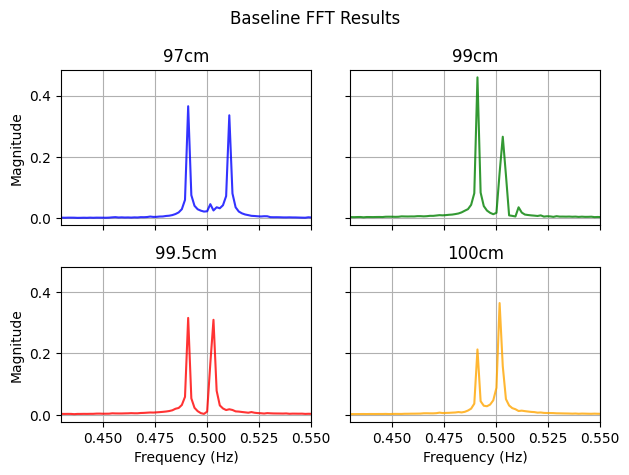

In [8]:
plot_fft_results_all(
    baseline_fit.fft_results, title="Baseline FFT Results", labels=baseline.labels
)
save_plot("salvaging/baseline_fft_results.pdf")
plt.show()
plot_fft_results_each(
    baseline_fit.fft_results, title="Baseline FFT Results", labels=baseline.labels
)
save_plot("salvaging/baseline_fft_results_each.pdf")
plt.show()

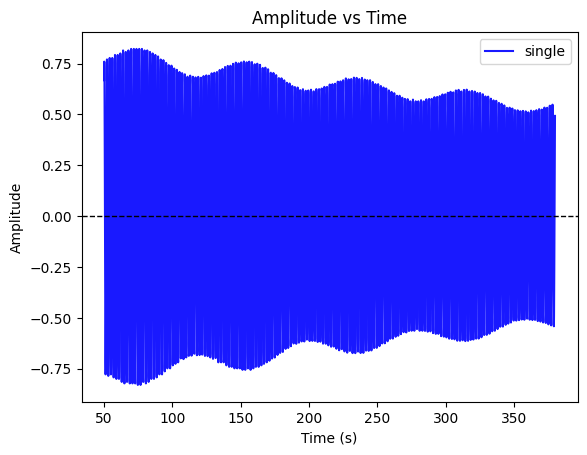

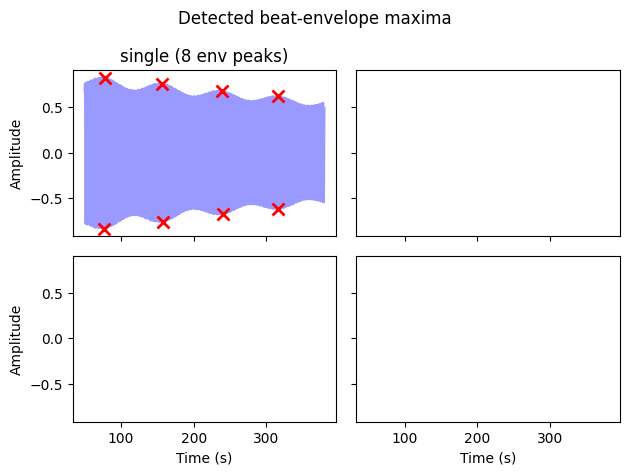

Single Pendulum Fit Results:
(['mass A'], [np.float64(0.002464821047412636)], [np.float64(0.0015763800632738612)])


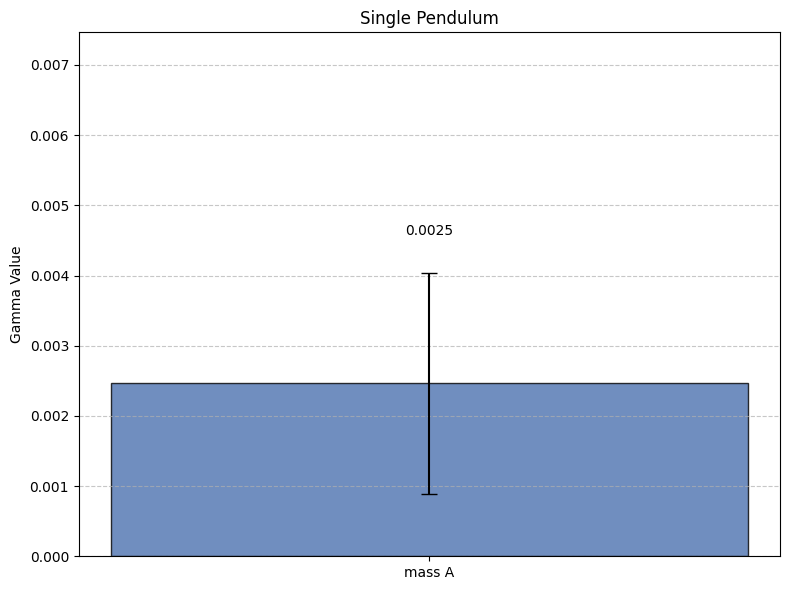

In [11]:
single_pendulum = PendulumsData(cols=["mass A"], labels=["single"], lengths=np.array([1.0]), data=prepare_data("../data/session-6/single-pendulum.csv", ["mass A"]))
single_pendulum.preprocess_offsets()
single_pendulum.normalize()
single_pendulum.drop_time_range(0, 50)

plot_all(single_pendulum)
plt.show()

single_pendulum_fit = ResonanceFitData(L_d, single_pendulum)

single_pendulum_fit.plot_detected_peaks()
plt.show()

single_pendulum_fit.fit_single_pendulums()

print("Single Pendulum Fit Results:")
print(single_pendulum_fit.get_data_to_plot())

bar_chart(single_pendulum_fit.get_data_to_plot(), title="Single Pendulum")
plt.show()

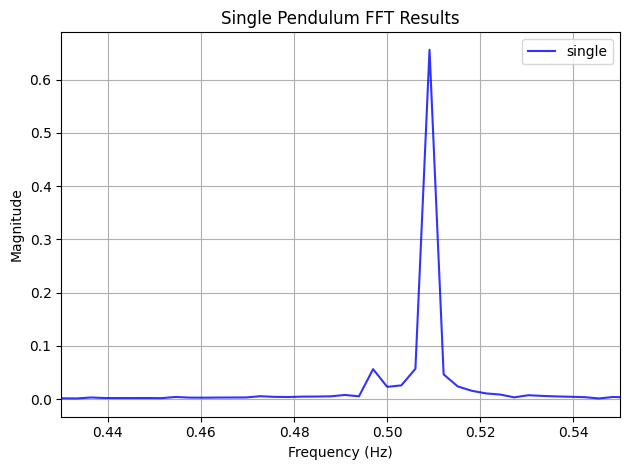

In [12]:
single_pendulum_fit.perform_fft()
plot_fft_results_all(
    single_pendulum_fit.fft_results,
    title="Single Pendulum FFT Results",
    labels=single_pendulum.labels,
)
plt.show()